In [1]:
import pandas as pd

data = {
    'Student': ['Abdullah', 'Aroob', 'Aminah', 'Azka', 'Owais', 'Tim', 'Liza', 'Martin'],
    'StudyHours': [2, 4, 3, 6, 4, 7, 3, 1],
    'Score': [67, 62, 61, 93, 76, 71, 69, 52]
}


def learn(data):
  df = pd.DataFrame(data)

  # Calculate means
  x_mean = df['StudyHours'].mean()
  y_mean = df['Score'].mean()

  # Calculate slope (a)
  df['x_diff'] = df['StudyHours'] - x_mean
  df['y_diff'] = df['Score'] - y_mean
  df['xy_product'] = df['x_diff'] * df['y_diff']
  df['x_diff_sq'] = df['x_diff'] ** 2
  numerator = df['xy_product'].sum()
  denominator = df['x_diff_sq'].sum()
  a = numerator / denominator

  # Calculate intercept (b)
  b = y_mean - a * x_mean

  # Return regression line and intermediate values
  return a, b


def predict(hours_of_study, a, b):
  prediction = a * hours_of_study + b
  return prediction

In [2]:
a, b = learn(data)
print(f"Values of a, b are {a}, {b}")
print(f"Predicted exam score for Sidra is {predict(4, a, b)}")
print(f"Predicted exam score for Zainab is {predict(6, a, b)}")
print(f"Predicted exam score for Fizza is {predict(9, a, b)}")

Values of a, b are 4.245454545454545, 52.95454545454545
Predicted exam score for Sidra is 69.93636363636364
Predicted exam score for Zainab is 78.42727272727272
Predicted exam score for Fizza is 91.16363636363636


## Multiple variables
The above example predicts the Exam score based on a single variable. In reality, we deal with many more features. Let's add another variable to our dataset called "SleepHours"

In [3]:
data = {
    'Student': ['Abdullah', 'Aroob', 'Aminah', 'Azka', 'Owais', 'Tim', 'Liza', 'Martin'],
    'StudyHours': [2, 4, 3, 6, 4, 7, 3, 1],
    'SleepHours': [7, 4, 5, 6, 6, 4, 8, 8],
    'Score': [67, 62, 61, 93, 76, 71, 69, 52]
}

def learn_multi(data):
    df = pd.DataFrame(data)

    # Calculate means
    x1_mean = df['StudyHours'].mean()
    x2_mean = df['SleepHours'].mean()
    y_mean = df['Score'].mean()

    # Differences
    df['x1_diff'] = df['StudyHours'] - x1_mean
    df['x2_diff'] = df['SleepHours'] - x2_mean
    df['y_diff'] = df['Score'] - y_mean

    # Coefficients for StudyHours and SleepHours
    a1_numerator = (df['x1_diff'] * df['y_diff']).sum()
    a1_denominator = (df['x1_diff'] ** 2).sum()
    a1 = a1_numerator / a1_denominator

    a2_numerator = (df['x2_diff'] * df['y_diff']).sum()
    a2_denominator = (df['x2_diff'] ** 2).sum()
    a2 = a2_numerator / a2_denominator

    # Intercept
    b = y_mean - (a1 * x1_mean + a2 * x2_mean)

    return a1, a2, b


def predict(study_hours, sleep_hours, a1, a2, b):
    return a1 * study_hours + a2 * sleep_hours + b

As can be observed, we now have 2 values for a, since there are 2 features. Also note how the equation of b is using both a1 and a2

In [4]:
a1, a2, b = learn_multi(data)
print(f"Values of a1, a2, b are {a1}, {a2}, {b}")
print(f"Predicted exam score for Summiya is {predict(3, 8, a1, a2, b)}")

Values of a1, a2, b are 4.245454545454545, -1.0, 58.95454545454545
Predicted exam score for Summiya is 63.69090909090909


# The Iris Dataset
The Iris dataset is a classic dataset in machine learning that contains measurements of different flower species to classify them based on their features. It was originally introduced by Ronald A. Fisher in 1936 for statistical analysis.
It consists of 150 samples of iris flowers, divided equally among 3 species: setosa, versicolor, and virginica.

Each sample includes 4 features:
*   Sepal length (in cm)
*   Sepal width (in cm)
*   Petal length (in cm)
*   Petal width (in cm)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
99                 5.7               2.8                4.1               1.3
41                 4.5               2.3                1.3               0.3
102                7.1               3.0                5.9               2.1
103                6.3               2.9                5.6               1.8
43                 5.0               3.5                1.6               0.6


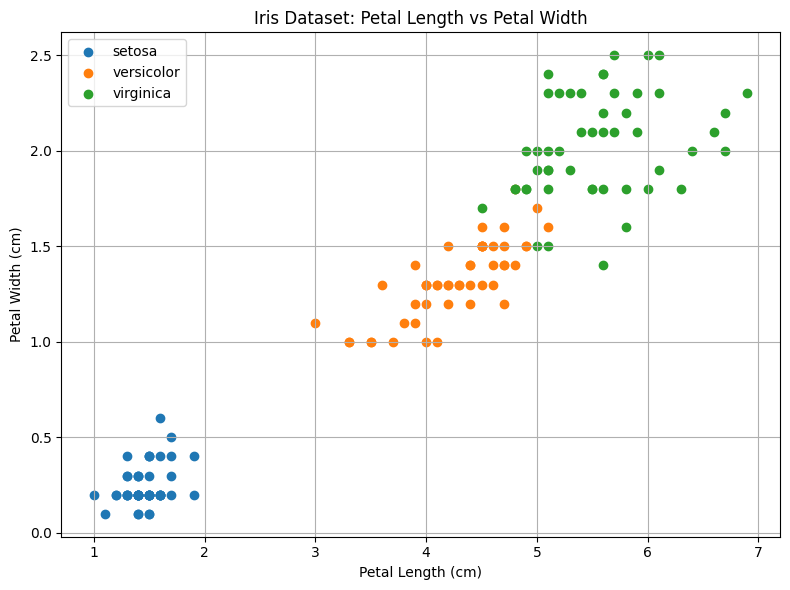

Coefficients: [-0.20726607  0.22282854  0.52408311]
Intercept: -0.24030738911226113
Predicted Petal Width: 0.22


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [5]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Load the Iris dataset
iris = load_iris()

# Convert into Pandas dataframe
df = pd.DataFrame(iris.data, columns=iris.feature_names)
# Shuffle and print the first 5 rows
shuffled_df = df.sample(frac=1)
print(shuffled_df.head())

# Convert numerical class labels in the Iris dataset into human-readable labels
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Scatter plot: Petal Length vs Petal Width, colored by species
plt.figure(figsize=(8, 6))

for species in df['species'].unique():
    subset = df[df['species'] == species]
    plt.scatter(
        subset['petal length (cm)'],
        subset['petal width (cm)'],
        label=species
    )
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Iris Dataset: Petal Length vs Petal Width')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Prepare input features (X) and target (y)
X = df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)']]
y = df['petal width (cm)']

# Create and train the linear regression model using Scikit learn library
model = LinearRegression()
model.fit(X, y)

# Print coefficients (a1, a2, ...) and intercept (b)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# Predict petal width
sample = [[4.9, 3.1, 1.5]]
predicted_width = model.predict(sample)
print("Predicted Petal Width:", round(predicted_width[0], 2))


In [6]:
print(df[df['petal length (cm)'] < 2.2])

    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                 5.1               3.5                1.4               0.2   
1                 4.9               3.0                1.4               0.2   
2                 4.7               3.2                1.3               0.2   
3                 4.6               3.1                1.5               0.2   
4                 5.0               3.6                1.4               0.2   
5                 5.4               3.9                1.7               0.4   
6                 4.6               3.4                1.4               0.3   
7                 5.0               3.4                1.5               0.2   
8                 4.4               2.9                1.4               0.2   
9                 4.9               3.1                1.5               0.1   
10                5.4               3.7                1.5               0.2   
11                4.8               3.4 

In [7]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Student data
data = {
    'Student': ['Abdullah', 'Aroob', 'Aminah', 'Azka', 'Owais', 'Tim', 'Liza', 'Martin'],
    'StudyHours': [2, 4, 3, 6, 4, 7, 3, 1],
    'SleepHours': [7, 4, 5, 6, 6, 4, 8, 8],
    'Age': [7, 4, 5, 6, 6, 4, 8, 8],
    'Score': [67, 62, 61, 93, 76, 71, 69, 52]
}

# Extract relevant columns and create DataFrame
student_df = pd.DataFrame(data)[['StudyHours', 'SleepHours', 'Score']]

# Create and train the model
model = LinearRegression()
X = student_df[['StudyHours', 'SleepHours']]
y = student_df['Score']
model.fit(X, y)

# Print coefficients and intercept
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# Example prediction
sample = [[3, 8]]  # Example input: StudyHours = 3, SleepHours = 8
predicted_score = model.predict(sample)
print("Predicted Score:", round(predicted_score[0], 2))

Coefficients: [6.78333333 4.65277778]
Intercept: 15.520833333333314
Predicted Score: 73.09


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
